In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42


# 各パス指定

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# 分類数設定

In [3]:
NUM_CLASSES = 35

# 学習データ読み込み

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 20)                860       
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
 dense_2 (Dense)             (None, 35)                385       
                                                                 
Total params: 1455 (5.68 KB)
Trainable params: 1455 (5.68 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


16/25 [==================>...........] - ETA: 0s - loss: 3.5601 - accuracy: 0.0439 
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
25/25 [==============================] - 2s 21ms/step - loss: 3.5262 - accuracy: 0.0585 - val_loss: 3.4497 - val_accuracy: 0.1136
Epoch 2/1000
16/25 [==================>...........] - ETA: 0s - loss: 3.3571 - accuracy: 0.1240

D:\hand-gesture-recognition-mediapipe-main\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
25/25 [==============================] - 0s 10ms/step - loss: 3.3013 - accuracy: 0.1387 - val_loss: 3.1116 - val_accuracy: 0.2319
Epoch 3/1000
19/25 [=====================>........] - ETA: 0s - loss: 2.9208 - accuracy: 0.2274
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
25/25 [==============================] - 0s 8ms/step - loss: 2.8565 - accuracy: 0.2417 - val_loss: 2.5290 - val_accuracy: 0.3549
Epoch 4/1000
17/25 [===================>..........] - ETA: 0s - loss: 2.3798 - accuracy: 0.3281
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
25/25 [==============================] - 0s 8ms/step - loss: 2.2903 - accuracy: 0.3466 - val_loss: 1.9632 - val_accuracy: 0.3728
Epoch 5/1000
19/25 [=====================>........] - ETA: 0s - loss: 1.9260 - accuracy: 0.3873
Epoch 5: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
25/25 [============

In [12]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

9/9 [==============================] - 0s 3ms/step - loss: 0.3996 - accuracy: 0.8892


In [13]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 171ms/step
[8.8643789e-01 1.4444125e-02 3.5818276e-04 4.0353424e-04 9.8100491e-02
 2.5572645e-04 1.9958615e-09 3.1286560e-09 4.4814223e-09 2.2250170e-08
 5.4662574e-10 4.9963245e-10 1.7010889e-09 6.5249588e-09 2.3739584e-09
 1.8810096e-09 6.2549016e-10 5.6391614e-10 2.5903999e-09 1.5641244e-09
 3.7892045e-10 2.1347060e-09 3.7325383e-09 4.2332813e-09 1.3893339e-09
 9.9105939e-11 3.4028349e-09 2.4505309e-09 1.2037743e-10 4.5068518e-10
 1.0229805e-08 2.2724433e-09 6.4208221e-09 2.5781155e-10 3.3572284e-10]
0


# 混同行列

34/34 [==============================] - 0s 2ms/step


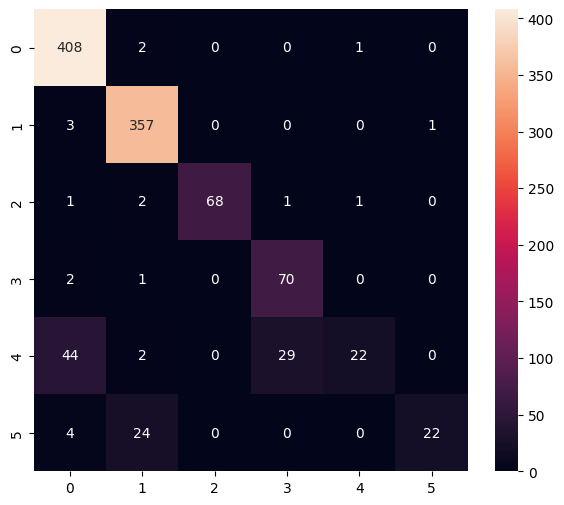

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       411
           1       0.92      0.99      0.95       361
           2       1.00      0.93      0.96        73
           3       0.70      0.96      0.81        73
           4       0.92      0.23      0.36        97
           5       0.96      0.44      0.60        50

    accuracy                           0.89      1065
   macro avg       0.90      0.76      0.77      1065
weighted avg       0.90      0.89      0.87      1065



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [16]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

D:\hand-gesture-recognition-mediapipe-main\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [17]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmpevft1497\assets


INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmpevft1497\assets


7924

# 推論テスト

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[8.8643789e-01 1.4444125e-02 3.5818276e-04 4.0353442e-04 9.8100513e-02
 2.5572645e-04 1.9958613e-09 3.1286558e-09 4.4814219e-09 2.2250170e-08
 5.4662463e-10 4.9963150e-10 1.7010920e-09 6.5249712e-09 2.3739581e-09
 1.8810096e-09 6.2549016e-10 5.6391614e-10 2.5903997e-09 1.5641183e-09
 3.7892042e-10 2.1347020e-09 3.7325378e-09 4.2332733e-09 1.3893311e-09
 9.9105932e-11 3.4028345e-09 2.4505307e-09 1.2037743e-10 4.5068518e-10
 1.0229804e-08 2.2724389e-09 6.4208221e-09 2.5781152e-10 3.3572281e-10]
0


In [23]:
import sys
print(sys.executable)

D:\hand-gesture-recognition-mediapipe-main\.venv\Scripts\python.exe
